In [1]:
%matplotlib inline
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from pathlib import Path
from sklearn.cluster import KMeans
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
CWD = Path().cwd().parent
DATASET_DIR = CWD / 'Datasets'
nasa_csv = DATASET_DIR / 'Processed Datasets' / 'NASA+EuropeanSpaceAgency_NEO_Data_Cleaned.csv'
try:
    df = pd.read_csv(nasa_csv)
except FileNotFoundError:
    print(f"Error: The file {nasa_csv} was not found.")
    exit(1)

| Group  | Key Orbital Features        |
| ------ | --------------------------- |
| Atira  | a < 1 AU, Q < 0.983 AU      |
| Aten   | a < 1 AU, Q > 0.983 AU      |
| Apollo | a > 1 AU, q < 1.017 AU      |
| Amor   | q ≥ 1.017 AU and q < 1.3 AU |


Semi_Major_Axis → 
𝑎


Perihelion_Distance → 
𝑞


Aphelion_Dist → 
𝑄

#### <span style="color:red">**Feature matrix:**</span>

In [3]:
X = df[[
    'Semi_Major_Axis', 
    'Perihelion_Distance', 
    'Aphelion_Dist', 
    'Eccentricity',
]]

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters
df.head()

,Absolute_Magnitude,Est_Dia_In_Km_Min,Est_Dia_In_Km_Max,Close_Approach_Date,Relative_Velocity_Km_Per_Hr,Miss_Dist_Kilometers,Minimum_Orbit_Intersection,Jupiter_Tisserand_Invariant,Epoch_Osculation,Eccentricity,...,Asc_Node_Longitude,Orbital_Period,Perihelion_Distance,Perihelion_Arg,Aphelion_Dist,Perihelion_Time,Mean_Anomaly,Mean_Motion,Hazardous,Cluster
0,21.6,0.127220,0.284472,1995-01-01,22017.003799,62753692.0,0.025282,4.634,2458000.5,0.425549,...,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,1,1
1,21.3,0.146068,0.326618,1995-01-01,65210.346095,57298148.0,0.186935,5.457,2458000.5,0.351674,...,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,0,3
2,20.3,0.231502,0.517654,1995-01-08,27326.560182,7622911.5,0.043058,4.557,2458000.5,0.348248,...,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,1,1
3,27.4,0.008801,0.019681,1995-01-15,40225.948191,42683616.0,0.005512,5.093,2458000.5,0.216578,...,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,0,1
4,21.6,0.127220,0.284472,1995-01-15,35426.991794,61010824.0,0.034798,5.154,2458000.5,0.210448,...,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,1,1


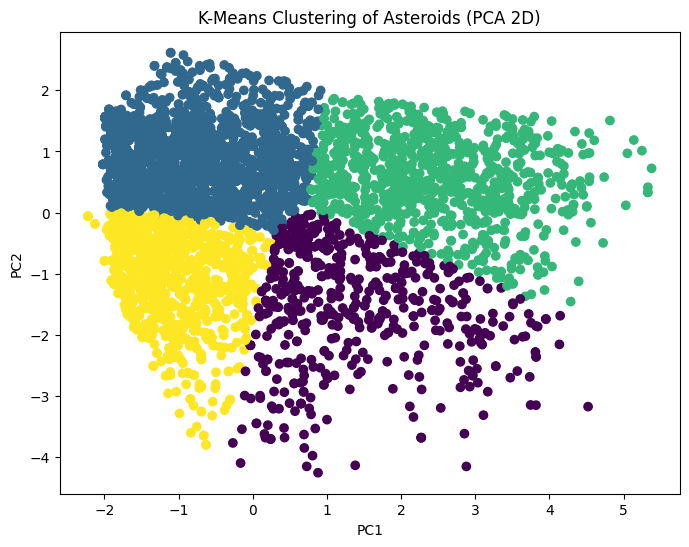

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0], X_pca[:,1],
    c=df['Cluster'],
    cmap='viridis'
)

plt.title('K-Means Clustering of Asteroids (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


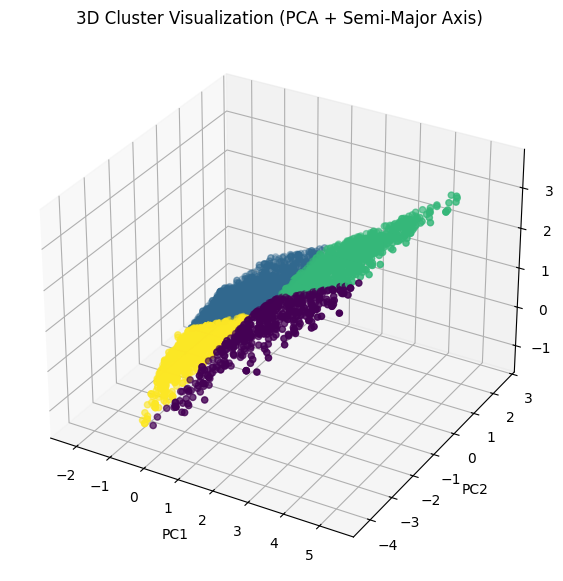

In [7]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    X_pca[:,0], X_pca[:,1], X_scaled[:,0],   # third axis = semi-major axis
    c=df['Cluster'], cmap='viridis'
)

ax.set_title('3D Cluster Visualization (PCA + Semi-Major Axis)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('Semi-Major Axis')
plt.show()


In [8]:
cluster_summary = df.groupby('Cluster')[['Semi_Major_Axis', 'Perihelion_Distance', 'Aphelion_Dist']].mean()
print(cluster_summary)


         Semi_Major_Axis  Perihelion_Distance  Aphelion_Dist
Cluster                                                     
0               1.705771             0.590712       2.820829
1               1.255293             0.952511       1.558075
2               2.229788             1.044736       3.414841
3               0.969112             0.578814       1.359409


NEA (Near-Earth Asteroid) Classification Table

Semi_Major_Axis → 
𝑎


Perihelion_Distance → 
𝑞


Aphelion_Dist → 
𝑄


Eccentricity → helps shape the orbit

| **Group**        | **Orbital Criterion**                           | **What It Means**                                                                                       |
| ---------------- | ----------------------------------------------- | ------------------------------------------------------------------------------------------------------- |
| **Atira (IEOs)** | ( a < 1.0 ) AU **and** ( Q < 0.983 ) AU         | Orbit entirely *inside* Earth’s orbit (rare “inner-Earth” asteroids).                                   |
| **Aten**         | ( a < 1.0 ) AU **and** ( Q > 0.983 ) AU         | Semi-major axis smaller than Earth’s, but aphelion extends *beyond* Earth’s orbit → **Earth-crossing**. |
| **Apollo**       | ( a > 1.0 ) AU **and** ( q < 1.017 ) AU         | Semi-major axis larger than Earth’s, but perihelion crosses Earth’s orbit → **Earth-crossing**.         |
| **Amor**         | ( a > 1.0 ) AU **and** ( 1.017 <= q < 1.3 ) AU | Do not cross Earth’s orbit but pass close to it → **Earth-approaching**.                                |




In [9]:
def classify(a, q, Q):
    if a < 1.0 and Q < 0.983:
        return "Atira"
    elif a < 1.0 and Q >= 0.983:
        return "Aten"
    elif a > 1.0 and q < 1.017:
        return "Apollo"
    else:
        return "Amor"

df['NASA_Class'] = df.apply(
    lambda row: classify(row['Semi_Major_Axis'], row['Perihelion_Distance'], row['Aphelion_Dist']),
    axis=1
)
df[['Cluster', 'NASA_Class']].head(10) 


,Cluster,NASA_Class
0,1,Apollo
1,3,Apollo
2,1,Apollo
3,1,Apollo
4,1,Apollo
5,0,Apollo
6,0,Apollo
7,3,Apollo
8,1,Apollo
9,3,Aten


In [10]:
pd.crosstab(df['Cluster'], df['NASA_Class'])


NASA_Class,Amor,Apollo,Aten,Atira
Cluster,,,,
0,0,552,3,0
1,541,1155,239,0
2,552,385,0,0
3,0,465,848,9


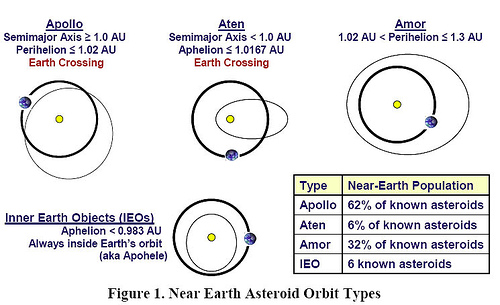

Reference: Frequently Asked Questions (FAQ). (2025). Nasa.gov. https://cneos.jpl.nasa.gov/faq/new.html#aten

‌

According to NASA, Of the four main classes of Near-Earth Objects, Apollo asteroids are the most common, followed by Amor, Aten, and Atira.

That is why cluster 0, 2 and 3 correspond mostly to the Apollo asteroid class while cluster 1 correspond to the Amor asteroid class.

No clusters corresponded to Aten or Atira, which indicates that these asteroid types are either rare in the dataset or their orbital characteristics do not produce distinct separations under K-Means

Most NEOs naturally fall into Apollo-type orbits, and even when forced to form four clusters, the data still forms three unique Apollo subgroups and one Amor group.

In [11]:
cluster_to_group = {
    0: "Apollo",
    1: "Amor",
    2: "Apollo",
    3: "Apollo"
}

df["NASA_Group_Cluster"] = df["Cluster"].map(cluster_to_group)


In [12]:
df[['Cluster', 'NASA_Class','NASA_Group_Cluster']].head(10) 


,Cluster,NASA_Class,NASA_Group_Cluster
0,1,Apollo,Amor
1,3,Apollo,Apollo
2,1,Apollo,Amor
3,1,Apollo,Amor
4,1,Apollo,Amor
5,0,Apollo,Apollo
6,0,Apollo,Apollo
7,3,Apollo,Apollo
8,1,Apollo,Amor
9,3,Aten,Apollo


In [13]:
# percentage of correct classifications
correct_classifications = np.sum(df['NASA_Class'] == df['NASA_Group_Cluster'])
total_classifications = len(df)
accuracy = correct_classifications / total_classifications
print(f"Clustering Accuracy: {accuracy:.2%}")

Clustering Accuracy: 40.91%


### why is the accuracy not 100%?
#### Possible reasons include:
 - Overlapping characteristics between asteroid classes
 - Limitations of K-Means clustering in capturing complex boundaries